
# Analyse statistique — *Mental Health in Medical Students*

Notebook Python pour explorer et interpréter le dataset **Carrard et al. 2022 MedTeach**.

## Objectifs
- comprendre la structure du dataset ;
- produire une **EDA** propre ;
- tester statistiquement plusieurs hypothèses ;
- modéliser les principaux déterminants de la santé mentale.

## Variables de santé mentale étudiées
- `cesd` : score dépressif
- `stai_t` : score d'anxiété-trait
- `mbi_ex` : épuisement émotionnel
- `mbi_cy` : cynisme
- `mbi_ea` : efficacité académique


In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid', context='notebook')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.stats import f_oneway, levene, shapiro
import warnings
warnings.filterwarnings('ignore')


In [ ]:
DATA_PATH = 'sample_data/Data Carrard et al. 2022 MedTeach.csv'
CODEBOOK_PATH = 'sample_data/Codebook Carrard et al. 2022 MedTeach.csv'


## 1. Chargement des données et du codebook

In [ ]:

df = pd.read_csv(DATA_PATH)
codebook = pd.read_csv(CODEBOOK_PATH, sep=';').iloc[:, :3]
codebook.columns = ['variable', 'label', 'scale']

print('Shape du dataset :', df.shape)
display(df.head())
display(codebook)


Shape du dataset : (886, 20)


,id,age,year,sex,glang,part,job,stud_h,health,psyt,jspe,qcae_cog,qcae_aff,amsp,erec_mean,cesd,stai_t,mbi_ex,mbi_cy,mbi_ea
0,2,18,1,1,120,1,0,56,3,0,88,62,27,17,0.738095,34,61,17,13,20
1,4,26,4,1,1,1,0,20,4,0,109,55,37,22,0.690476,7,33,14,11,26
2,9,21,3,2,1,0,0,36,3,0,106,64,39,17,0.690476,25,73,24,7,23
3,10,21,2,2,1,0,1,51,5,0,101,52,33,18,0.833333,17,48,16,10,21
4,13,21,3,1,1,1,0,22,4,0,102,58,28,21,0.690476,14,46,22,14,23


,variable,label,scale
0,id,Participants ID number,string
1,age,age at questionnaire 20-21,numeric
2,year,CURICULUM YEAR : In which curriculum year are ...,1=Bmed1; 2=Bmed2; 3=Bmed3; 4=Mmed1; 5=Mmed2; 6...
3,sex,GENDER : To which gender do you identify the m...,1=Man; 2=Woman; 3=Non-binary
4,glang,MOTHER TONGUE: What is your mother tongue?,1=French; 15=German; 20=English; 37=Arab; 51=B...
5,part,PARTNERSHIP STATUS : Do you have a partner?,0=No; 1=Yes
6,job,HAVING A JOB : Do you have a paid job?,0=No; 1=Yes
7,stud_h,"HOURS OF STUDY PER WEEK : On average, how many...",NaN
8,health,SATISFACTION WITH HEALTH : How satisfied are y...,1=Verydissatisfied; 2=Dissatisfied; 3=Neithers...
9,psyt,PSYCHOTHERAPY LAST YEAR : During the last 12 m...,0=No; 1=Yes


## 2. Dictionnaire des variables et recodage des catégories

In [ ]:

def parse_scale(scale):
    if pd.isna(scale):
        return None
    scale = str(scale)
    if '=' not in scale:
        return None
    mapping = {}
    for item in scale.split(';'):
        item = item.strip()
        if '=' in item:
            k, v = item.split('=', 1)
            k = k.strip()
            v = v.strip()
            try:
                mapping[int(k)] = v
            except:
                mapping[k] = v
    return mapping if mapping else None

mappings = {row.variable: parse_scale(row.scale) for _, row in codebook.iterrows()}
mappings = {k: v for k, v in mappings.items() if v is not None}
mappings


{'year': {1: 'Bmed1',
  2: 'Bmed2',
  3: 'Bmed3',
  4: 'Mmed1',
  5: 'Mmed2',
  6: 'Mmed3'},
 'sex': {1: 'Man', 2: 'Woman', 3: 'Non-binary'},
 'glang': {1: 'French',
  15: 'German',
  20: 'English',
  37: 'Arab',
  51: 'Basque',
  52: 'Bulgarian',
  53: 'Catalan',
  54: 'Chinese',
  59: 'Korean',
  60: 'Croatian',
  62: 'Danish',
  63: 'Spanish',
  82: 'Estonian',
  83: 'Finnish',
  84: 'Galician',
  85: 'Greek',
  86: 'Hebrew',
  87: 'Hindi',
  88: 'Hungarian',
  89: 'Indonesian',
  90: 'Italian',
  92: 'Japanese',
  93: 'Kazakh',
  94: 'Latvian',
  95: 'Lithuanian',
  96: 'Malay',
  98: 'Dutch',
  100: 'Norwegian',
  101: 'Polish',
  102: 'Portuguese',
  104: 'Romanian',
  106: 'Russian',
  108: 'Serbian',
  112: 'Slovak',
  113: 'Slovenian',
  114: 'Swedish',
  116: 'Czech',
  117: 'Thai',
  118: 'Turkish',
  119: 'Ukrainian',
  120: 'Vietnamese',
  121: 'Other'},
 'part': {0: 'No', 1: 'Yes'},
 'job': {0: 'No', 1: 'Yes'},
 'health': {1: 'Verydissatisfied',
  2: 'Dissatisfied',
  3: 

In [ ]:

df_clean = df.copy()

for col, mapping in mappings.items():
    if col in df_clean.columns:
        df_clean[col + '_label'] = df_clean[col].map(mapping)

# Version lisible pour quelques variables clés
if 'sex_label' in df_clean:
    df_clean['sex_label'] = df_clean['sex_label'].replace({'Man': 'Homme', 'Woman': 'Femme', 'Non-binary': 'Non-binaire'})
if 'part_label' in df_clean:
    df_clean['part_label'] = df_clean['part_label'].replace({'Yes': 'Oui', 'No': 'Non'})
if 'job_label' in df_clean:
    df_clean['job_label'] = df_clean['job_label'].replace({'Yes': 'Oui', 'No': 'Non'})
if 'psyt_label' in df_clean:
    df_clean['psyt_label'] = df_clean['psyt_label'].replace({'Yes': 'Oui', 'No': 'Non'})

year_map_fr = {1:'BMed1', 2:'BMed2', 3:'BMed3', 4:'MMed1', 5:'MMed2', 6:'MMed3'}
df_clean['year_label'] = df_clean['year'].map(year_map_fr)

display(df_clean.head())


,id,age,year,sex,glang,part,job,stud_h,health,psyt,...,mbi_ex,mbi_cy,mbi_ea,year_label,sex_label,glang_label,part_label,job_label,health_label,psyt_label
0,2,18,1,1,120,1,0,56,3,0,...,17,13,20,BMed1,Homme,Vietnamese,Oui,Non,Neithersatisfiednordissatisfied,Non
1,4,26,4,1,1,1,0,20,4,0,...,14,11,26,MMed1,Homme,French,Oui,Non,Satisfied,Non
2,9,21,3,2,1,0,0,36,3,0,...,24,7,23,BMed3,Femme,French,Non,Non,Neithersatisfiednordissatisfied,Non
3,10,21,2,2,1,0,1,51,5,0,...,16,10,21,BMed2,Femme,French,Non,Oui,Verysatisfied,Non
4,13,21,3,1,1,1,0,22,4,0,...,22,14,23,BMed3,Homme,French,Oui,Non,Satisfied,Non


## 3. Contrôle qualité : types, doublons, valeurs manquantes

,dtype,missing_n,missing_%,n_unique
id,int64,0,0.0,886
stud_h,int64,0,0.0,61
stai_t,int64,0,0.0,57
cesd,int64,0,0.0,55
jspe,int64,0,0.0,49
qcae_cog,int64,0,0.0,40
qcae_aff,int64,0,0.0,29
amsp,int64,0,0.0,29
mbi_ea,int64,0,0.0,27
mbi_ex,int64,0,0.0,26


Nombre de doublons sur id : 0



## 4. Statistiques descriptives

On sépare :
- les **variables quantitatives** ;
- les **variables qualitatives** principales (`sex`, `year`, `part`, `job`, `psyt`, `health`).


In [ ]:

mental_vars = ['cesd', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']
quant_vars = ['age', 'stud_h', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean'] + mental_vars
cat_vars = ['sex_label', 'year_label', 'part_label', 'job_label', 'psyt_label', 'health']

desc = df_clean[quant_vars].describe().T
# ajout IQR
q1 = df_clean[quant_vars].quantile(0.25)
q3 = df_clean[quant_vars].quantile(0.75)
desc['IQR'] = q3 - q1
display(desc.round(3))

for col in ['sex_label', 'year_label', 'part_label', 'job_label', 'psyt_label']:
    print(f'\nRépartition — {col}')
    display(pd.DataFrame({
        'n': df_clean[col].value_counts(dropna=False),
        '%': (df_clean[col].value_counts(normalize=True, dropna=False) * 100).round(1)
    }))


,count,mean,std,min,25%,50%,75%,max,IQR
age,886.0,22.384,3.301,17.000,20.000,22.000,24.000,49.000,4.000
stud_h,886.0,25.289,15.928,0.000,12.000,25.000,36.000,70.000,24.000
jspe,886.0,106.375,8.784,67.000,101.000,107.000,113.000,125.000,12.000
qcae_cog,886.0,58.526,6.570,37.000,54.000,58.000,63.000,76.000,9.000
qcae_aff,886.0,34.784,5.377,18.000,31.000,35.000,39.000,48.000,8.000
amsp,886.0,23.150,4.993,6.000,20.000,23.000,26.750,35.000,6.750
erec_mean,886.0,0.720,0.094,0.357,0.667,0.726,0.786,0.952,0.119
cesd,886.0,18.051,11.479,0.000,9.000,16.000,25.000,56.000,16.000
stai_t,886.0,42.898,11.978,20.000,34.000,43.000,51.000,77.000,17.000
mbi_ex,886.0,16.878,5.256,5.000,13.000,17.000,20.000,30.000,7.000



Répartition — sex_label


,n,%
sex_label,,
Femme,606,68.4
Homme,275,31.0
Non-binaire,5,0.6



Répartition — year_label


,n,%
year_label,,
BMed1,245,27.7
BMed3,143,16.1
BMed2,135,15.2
MMed2,127,14.3
MMed1,123,13.9
MMed3,113,12.8


...

,n,%
part_label,,
Oui,499,56.3
Non,387,43.7



Répartition — job_label


,n,%
job_label,,
Non,577,65.1
Oui,309,34.9



Répartition — psyt_label


,n,%
psyt_label,,
Non,687,77.5
Oui,199,22.5


## 5. Distribution des variables de santé mentale

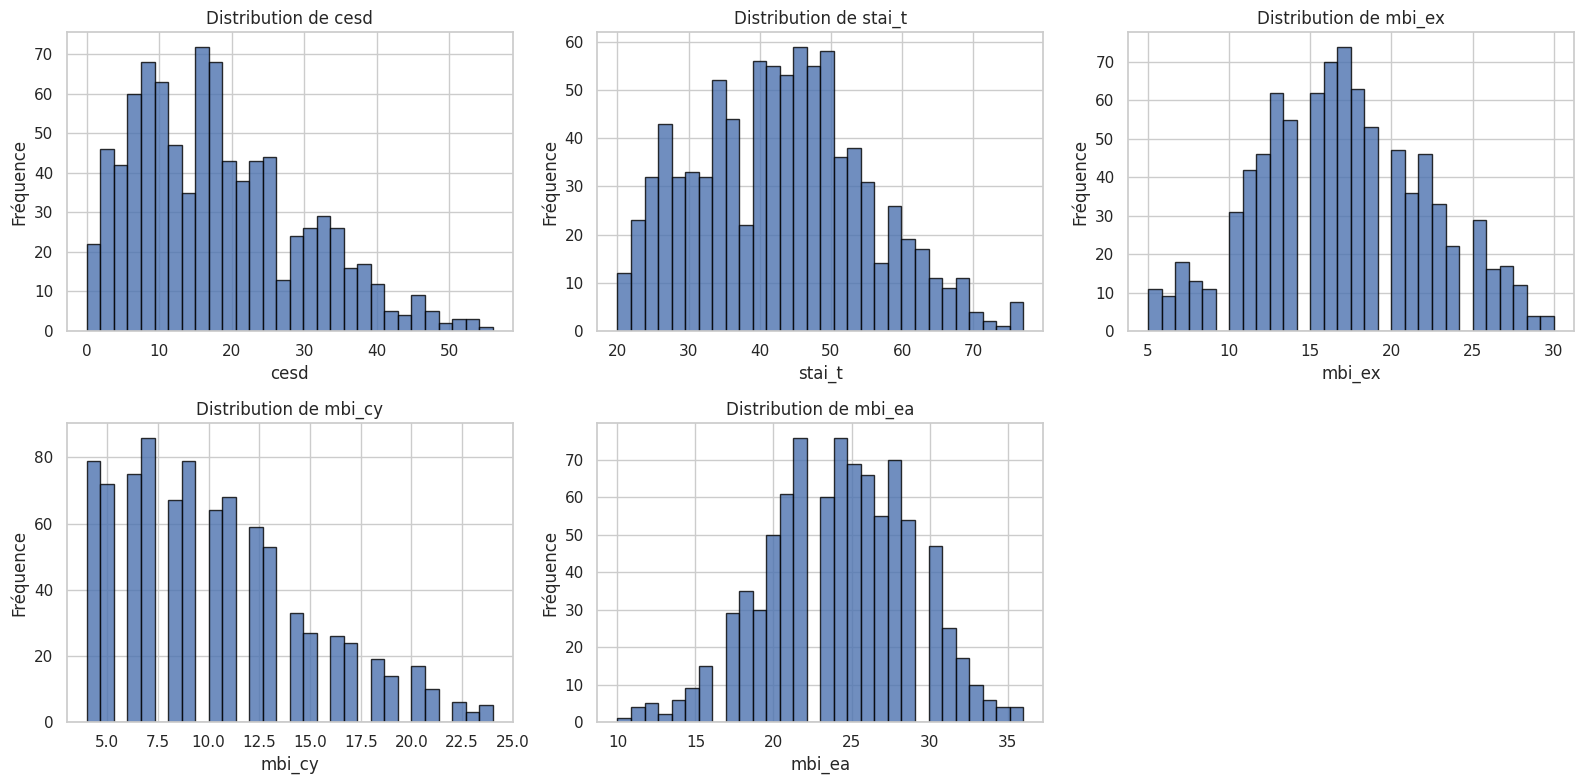

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(mental_vars):
    axes[i].hist(df_clean[col], bins=30, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
for j in range(len(mental_vars), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## 6. Corrélations entre variables quantitatives

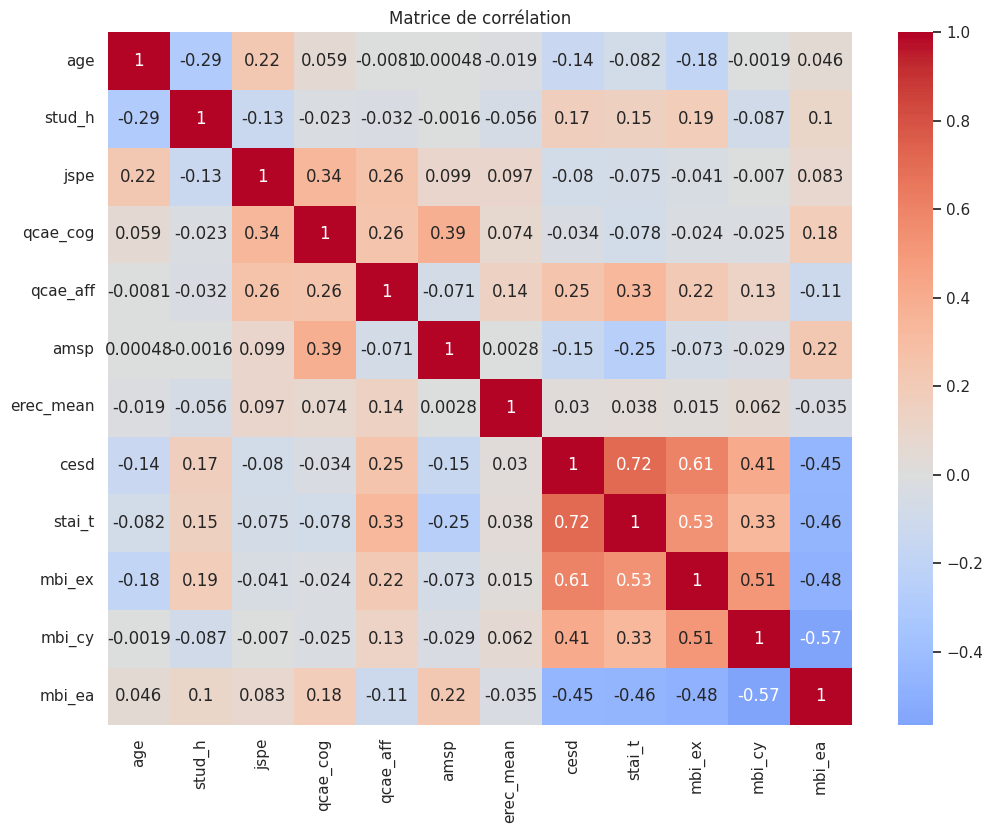

,cesd,stai_t,mbi_ex,mbi_cy,mbi_ea
cesd,1.000,0.716,0.606,0.408,-0.454
stai_t,0.716,1.000,0.530,0.332,-0.463
mbi_ex,0.606,0.530,1.000,0.505,-0.481
mbi_cy,0.408,0.332,0.505,1.000,-0.566
qcae_aff,0.251,0.331,0.216,0.128,-0.114
stud_h,0.174,0.152,0.186,-0.087,0.102
erec_mean,0.030,0.038,0.015,0.062,-0.035
qcae_cog,-0.034,-0.078,-0.024,-0.025,0.184
jspe,-0.080,-0.075,-0.041,-0.007,0.083
age,-0.139,-0.082,-0.183,-0.002,0.046


In [ ]:

corr = df_clean[quant_vars].corr(method='pearson')
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title('Matrice de corrélation')
plt.show()

corr_mental = corr[mental_vars].sort_values(by='cesd', ascending=False)
display(corr_mental.round(3))


Nombre d'observations : 886
Nombre de variables : 12

Après standardisation :
  Moyennes : [-0.  0. -0.  0.  0. -0.  0.  0. -0. -0.  0.  0.]
  Écarts-types : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- VARIANCE EXPLIQUÉE ---
CP     Variance (%)    Cumulée (%)     λ (val. propre)
-------------------------------------------------------
PC1            27.05          27.05           3.25
PC2            14.95          42.00           1.80
PC3            11.77          53.78           1.41
PC4             9.16          62.94           1.10
PC5             8.16          71.09           0.98
PC6             6.13          77.22           0.74
PC7             5.71          82.94           0.69
PC8             4.35          87.29           0.52
PC9             4.05          91.34           0.49
PC10            3.46          94.79           0.42
PC11            3.06          97.85           0.37
PC12            2.15         100.00           0.26

→ Critère de Kaiser (λ > 1) : 4 composantes
→ Critèr

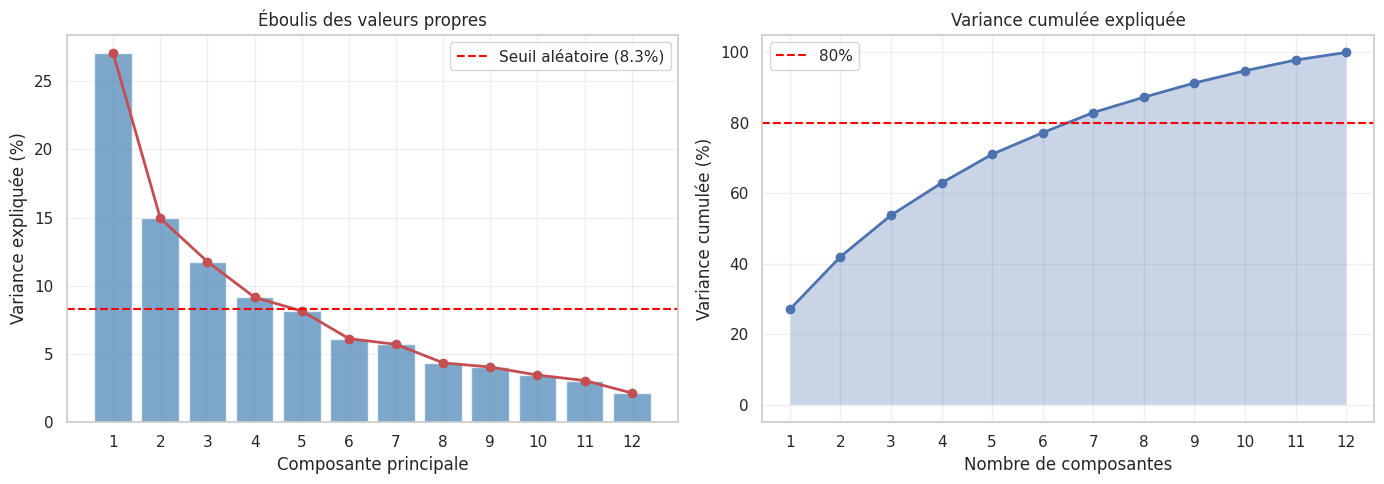

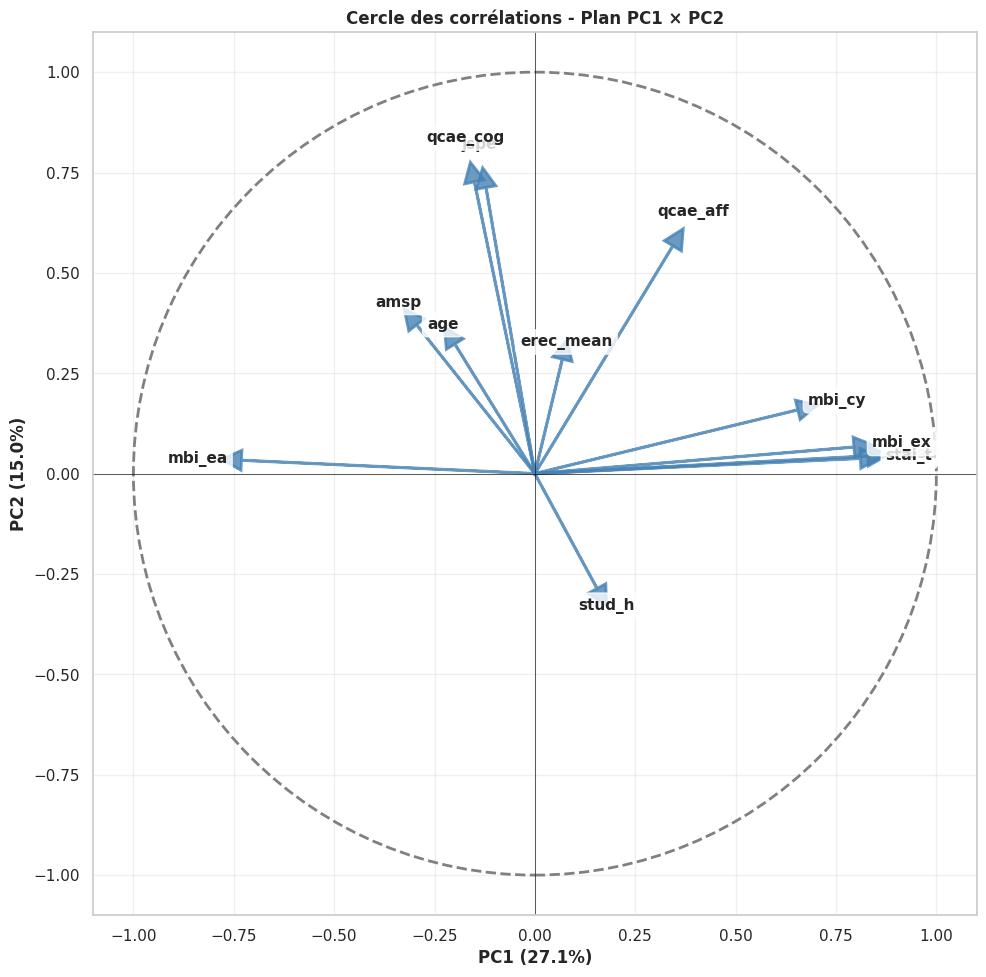

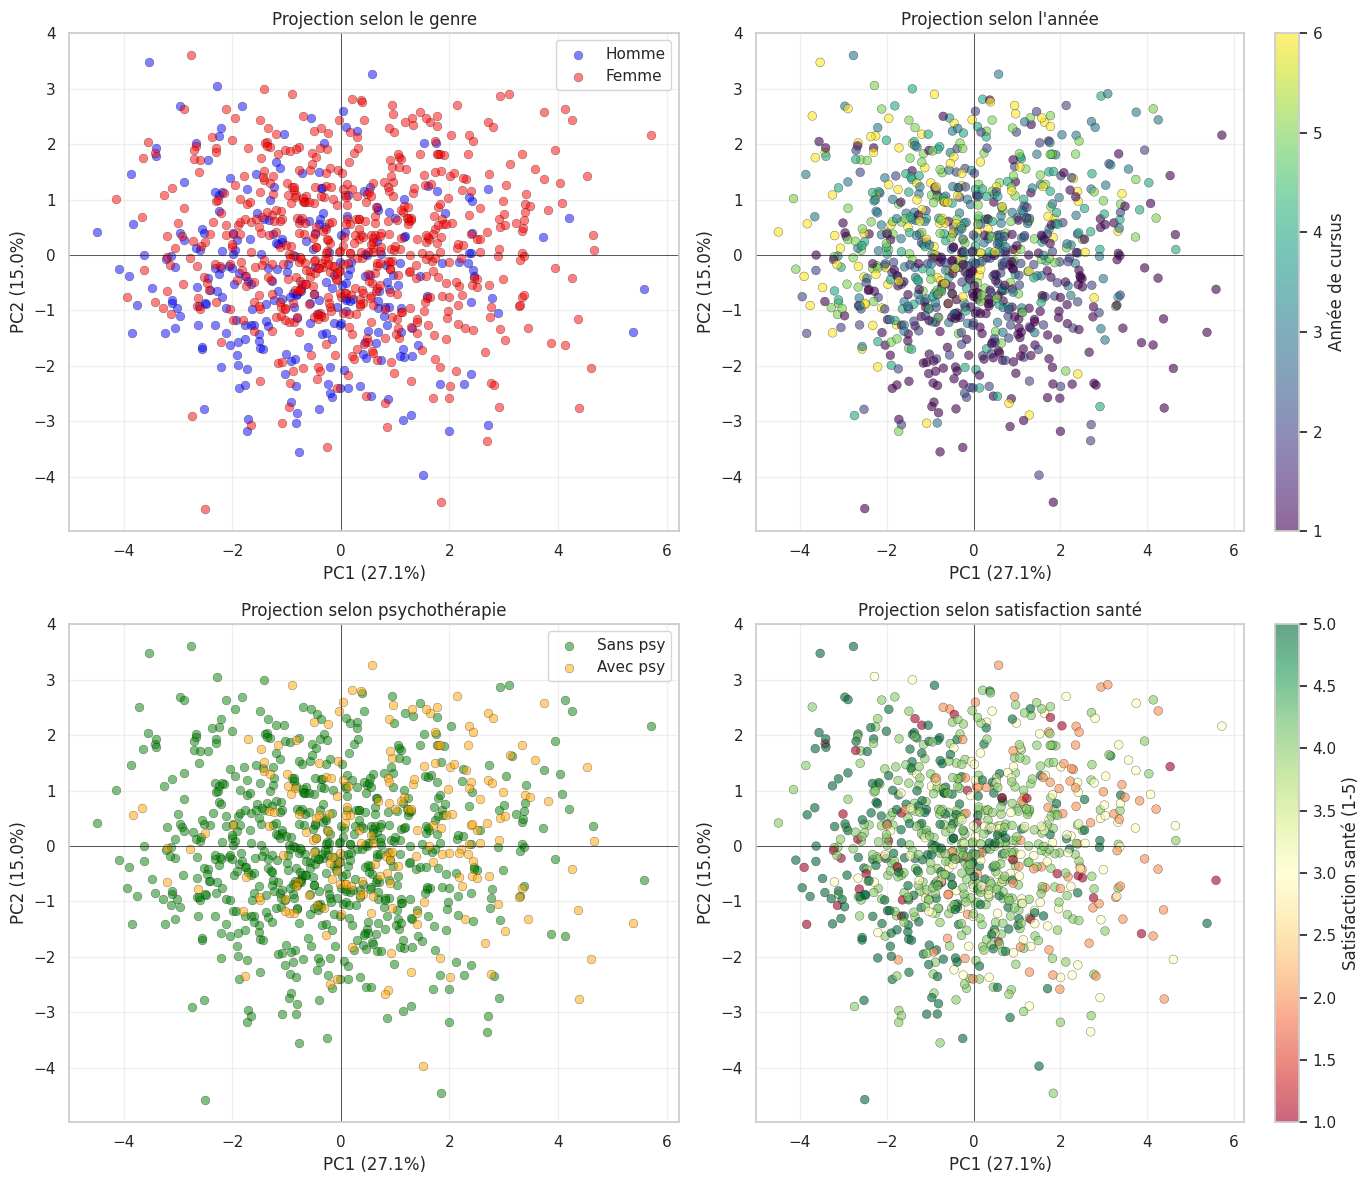

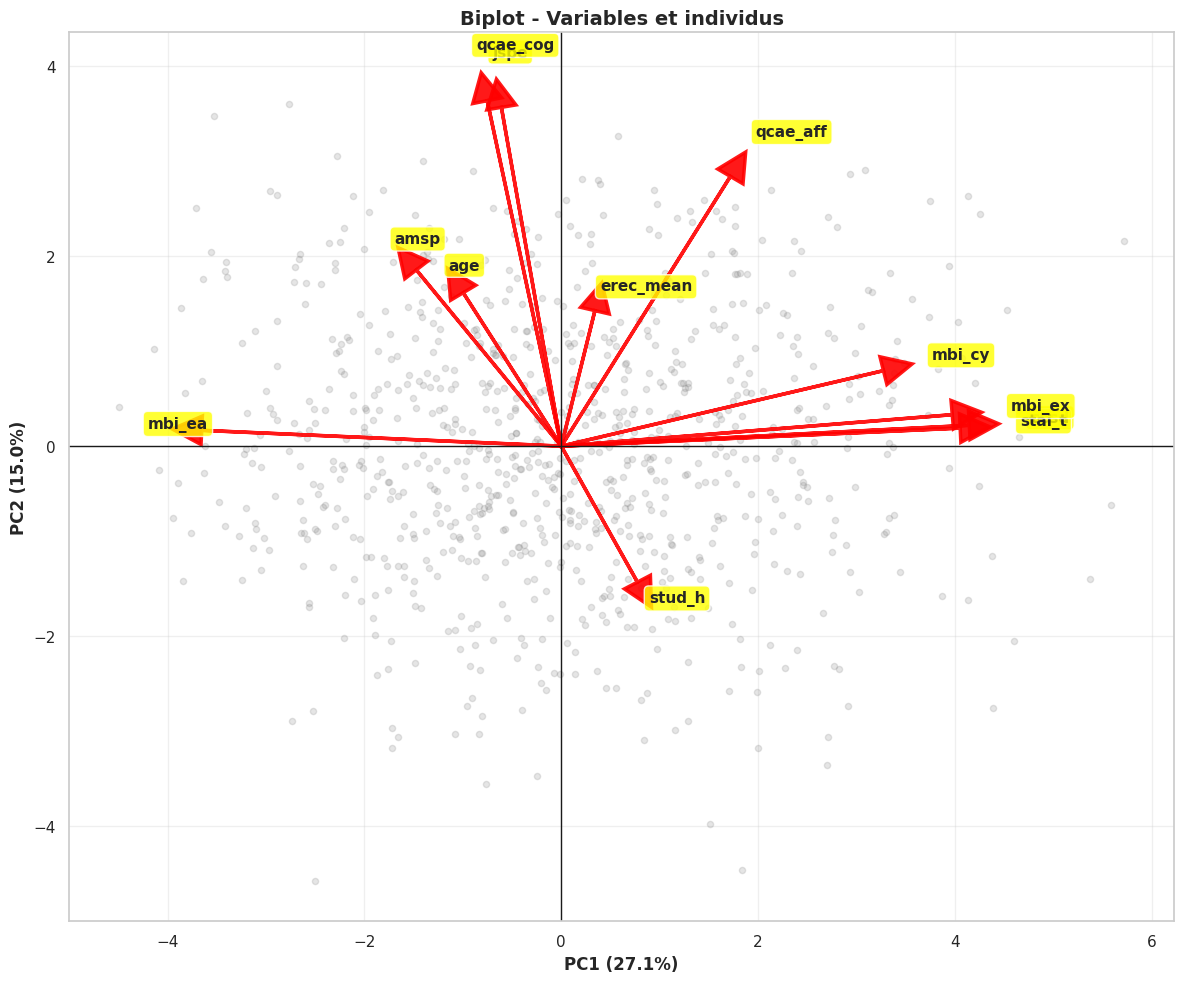


ANALYSE TERMINÉE
✓ 4 graphiques sauvegardés dans /
✓ Scores individuels : acp_scores_individus.csv
✓ Loadings : acp_loadings.csv


In [ ]:
"""
ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
Santé mentale des étudiants en médecine

Ce script réalise une ACP complète avec visualisations.
"""

# ==============================================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==============================================================================

# Charger les données
df = pd.read_csv(DATA_PATH)

# Variables quantitatives pour l'ACP
quant_vars = ['age', 'stud_h', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp',
              'erec_mean', 'cesd', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']

# Supprimer les valeurs manquantes
df_clean = df[quant_vars].dropna()

print(f"Nombre d'observations : {len(df_clean)}")
print(f"Nombre de variables : {len(quant_vars)}")

# ==============================================================================
# 2. STANDARDISATION DES VARIABLES
# ==============================================================================
# IMPORTANT : L'ACP nécessite de standardiser les variables pour que toutes
# contribuent équitablement, indépendamment de leur échelle de mesure

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("\nAprès standardisation :")
print(f"  Moyennes : {X_scaled.mean(axis=0).round(2)}")
print(f"  Écarts-types : {X_scaled.std(axis=0).round(2)}")

# ==============================================================================
# 3. CALCUL DE L'ACP
# ==============================================================================

# Créer l'objet PCA (sans limite de composantes)
pca = PCA()

# Appliquer l'ACP (transformer les données dans le nouvel espace)
X_pca = pca.fit_transform(X_scaled)

# Résultats de l'ACP
variance_explained = pca.explained_variance_ratio_  # Variance expliquée par chaque CP
cumulative_variance = np.cumsum(variance_explained)  # Variance cumulée
eigenvalues = pca.explained_variance_  # Valeurs propres (λ)
loadings = pca.components_.T * np.sqrt(eigenvalues)  # Loadings (corrélations)

# Afficher la variance expliquée
print("\n--- VARIANCE EXPLIQUÉE ---")
print(f"{'CP':<6} {'Variance (%)':<15} {'Cumulée (%)':<15} {'λ (val. propre)'}")
print("-" * 55)
for i in range(len(variance_explained)):
    print(f"PC{i+1:<4} {variance_explained[i]*100:>13.2f}  "
          f"{cumulative_variance[i]*100:>13.2f}  {eigenvalues[i]:>13.2f}")

# Critères de sélection du nombre de composantes
n_kaiser = sum(eigenvalues > 1)  # Critère de Kaiser (λ > 1)
n_80 = np.argmax(cumulative_variance >= 0.80) + 1  # 80% de variance

print(f"\n→ Critère de Kaiser (λ > 1) : {n_kaiser} composantes")
print(f"→ Critère 80% de variance : {n_80} composantes")
print(f"→ PC1 + PC2 expliquent : {cumulative_variance[1]*100:.2f}%")

# ==============================================================================
# 4. INTERPRÉTATION DES COMPOSANTES PRINCIPALES
# ==============================================================================

print("\n--- INTERPRÉTATION DES CP ---")

# PC1 : Variables les plus corrélées
print("\nPC1 (variables triées par loading absolu) :")
pc1_df = pd.DataFrame({
    'Variable': quant_vars,
    'Loading': loadings[:, 0]
}).sort_values('Loading', key=abs, ascending=False)
print(pc1_df.to_string(index=False))

# PC2 : Variables les plus corrélées
print("\nPC2 (variables triées par loading absolu) :")
pc2_df = pd.DataFrame({
    'Variable': quant_vars,
    'Loading': loadings[:, 1]
}).sort_values('Loading', key=abs, ascending=False)
print(pc2_df.to_string(index=False))

# ==============================================================================
# 5. QUALITÉ DE REPRÉSENTATION (COS²)
# ==============================================================================

# Cos² = carré des loadings (qualité de représentation sur un axe)
cos2_pc1 = loadings[:, 0] ** 2
cos2_pc2 = loadings[:, 1] ** 2
cos2_total = cos2_pc1 + cos2_pc2

quality_df = pd.DataFrame({
    'Variable': quant_vars,
    'Cos²_PC1': cos2_pc1,
    'Cos²_PC2': cos2_pc2,
    'Cos²_Total': cos2_total
}).sort_values('Cos²_Total', ascending=False)

print("\n--- QUALITÉ DE REPRÉSENTATION (COS²) ---")
print(quality_df.round(3).to_string(index=False))

well_represented = quality_df[quality_df['Cos²_Total'] >= 0.5]
print(f"\n→ Variables bien représentées (Cos² ≥ 0.5) : {len(well_represented)}")
print(well_represented['Variable'].tolist())

# ==============================================================================
# 6. CONTRIBUTIONS DES VARIABLES
# ==============================================================================

# Contribution = (loading²) / somme(loading²) pour chaque CP
contributions = (loadings ** 2) / (loadings ** 2).sum(axis=0) * 100

contrib_df = pd.DataFrame({
    'Variable': quant_vars,
    'Contrib_PC1 (%)': contributions[:, 0],
    'Contrib_PC2 (%)': contributions[:, 1]
}).sort_values('Contrib_PC1 (%)', ascending=False)

print("\n--- CONTRIBUTIONS AUX CP (%) ---")
print(contrib_df.round(2).to_string(index=False))

# ==============================================================================
# 7. VISUALISATION 1 : ÉBOULIS DES VALEURS PROPRES (SCREE PLOT)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée par composante
ax1 = axes[0]
components = np.arange(1, len(variance_explained) + 1)
ax1.bar(components, variance_explained * 100, alpha=0.7, color='steelblue')
ax1.plot(components, variance_explained * 100, 'ro-', linewidth=2)
ax1.axhline(y=100/len(quant_vars), color='red', linestyle='--',
            label=f'Seuil aléatoire ({100/len(quant_vars):.1f}%)')
ax1.set_xlabel('Composante principale')
ax1.set_ylabel('Variance expliquée (%)')
ax1.set_title('Éboulis des valeurs propres')
ax1.set_xticks(components)
ax1.legend()
ax1.grid(alpha=0.3)

# Variance cumulée
ax2 = axes[1]
ax2.plot(components, cumulative_variance * 100, 'bo-', linewidth=2)
ax2.axhline(y=80, color='red', linestyle='--', label='80%')
ax2.fill_between(components, 0, cumulative_variance * 100, alpha=0.3)
ax2.set_xlabel('Nombre de composantes')
ax2.set_ylabel('Variance cumulée (%)')
ax2.set_title('Variance cumulée expliquée')
ax2.set_xticks(components)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('acp_simple_scree.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 8. VISUALISATION 2 : CERCLE DES CORRÉLATIONS (PC1 vs PC2)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Cercle unitaire
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=2)
ax.add_patch(circle)

# Axes
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# Vecteurs des variables (flèches)
for i, var in enumerate(quant_vars):
    x, y = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05,
             fc='steelblue', ec='steelblue', linewidth=2, alpha=0.8)
    ax.text(x * 1.15, y * 1.15, var, fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontweight='bold')
ax.set_title('Cercle des corrélations - Plan PC1 × PC2', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('acp_simple_cercle.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 9. VISUALISATION 3 : PROJECTION DES INDIVIDUS
# ==============================================================================

# Récupérer les variables catégorielles pour coloration
df_full = df.loc[df_clean.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Projection par genre
ax1 = axes[0, 0]
for sex, label, color in [(1, 'Homme', 'blue'), (2, 'Femme', 'red')]:
    mask = df_full['sex'] == sex
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=40,
                c=color, label=label, edgecolors='black', linewidth=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)')
ax1.set_title('Projection selon le genre')
ax1.legend()
ax1.grid(alpha=0.3)

# Projection par année
ax2 = axes[0, 1]
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df_full['year'],
                     cmap='viridis', alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)
plt.colorbar(scatter, ax=ax2, label='Année de cursus')
ax2.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)')
ax2.set_title('Projection selon l\'année')
ax2.grid(alpha=0.3)

# Projection par psychothérapie
ax3 = axes[1, 0]
for psyt, label, color in [(0, 'Sans psy', 'green'), (1, 'Avec psy', 'orange')]:
    mask = df_full['psyt'] == psyt
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=40,
                c=color, label=label, edgecolors='black', linewidth=0.3)
ax3.axhline(y=0, color='k', linewidth=0.5)
ax3.axvline(x=0, color='k', linewidth=0.5)
ax3.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)')
ax3.set_title('Projection selon psychothérapie')
ax3.legend()
ax3.grid(alpha=0.3)

# Projection par satisfaction de santé
ax4 = axes[1, 1]
scatter = ax4.scatter(X_pca[:, 0], X_pca[:, 1], c=df_full['health'],
                     cmap='RdYlGn', alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
ax4.axhline(y=0, color='k', linewidth=0.5)
ax4.axvline(x=0, color='k', linewidth=0.5)
plt.colorbar(scatter, ax=ax4, label='Satisfaction santé (1-5)')
ax4.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)')
ax4.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)')
ax4.set_title('Projection selon satisfaction santé')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('acp_simple_projections.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 10. BIPLOT (Variables + Individus sur le même graphique)
# ==============================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Individus (nuage de points gris)
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=20, c='gray')

# Variables (vecteurs agrandis pour visibilité)
scale = 5  # Facteur d'échelle pour les flèches
for i, var in enumerate(quant_vars):
    x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.arrow(0, 0, x, y, head_width=0.3, head_length=0.3,
             fc='red', ec='red', linewidth=2.5, alpha=0.9)
    ax.text(x * 1.15, y * 1.15, var, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontweight='bold')
ax.set_title('Biplot - Variables et individus', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('acp_simple_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 11. EXPORT DES RÉSULTATS
# ==============================================================================

# Sauvegarder les scores des individus sur les CP
scores_df = pd.DataFrame(
    X_pca[:, :4],  # Garder les 4 premières CP
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=df_clean.index
)
scores_df.to_csv('acp_scores_individus.csv', index=True)

# Sauvegarder les loadings
loadings_df = pd.DataFrame(
    loadings[:, :4],
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=quant_vars
)
loadings_df.to_csv('acp_loadings.csv', index=True)

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)
print(f"✓ 4 graphiques sauvegardés dans /")
print(f"✓ Scores individuels : acp_scores_individus.csv")
print(f"✓ Loadings : acp_loadings.csv")
print("="*60)



## 7. Comparaisons de groupes

Hypothèses testées :
- différences selon le **genre** ;
- différences selon l'**année de cursus** ;
- différences selon le recours à une **psychothérapie / psychiatrie sur les 12 derniers mois** ;
- lien entre **satisfaction de santé** et scores de santé mentale.


In [ ]:

def cohens_d(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1) ** 2 + (ny - 1) * y.std(ddof=1) ** 2) / dof)
    return (x.mean() - y.mean()) / pooled_std

def compare_two_groups(data, group_col, target_col):
    groups = [g[target_col].dropna().values for _, g in data.groupby(group_col)]
    labels = list(data[group_col].dropna().unique())
    if len(groups) != 2:
        raise ValueError('Cette fonction attend exactement 2 groupes.')
    t_stat, p_val = stats.ttest_ind(groups[0], groups[1], equal_var=False)
    d = cohens_d(groups[0], groups[1])
    summary = data.groupby(group_col)[target_col].agg(['count', 'mean', 'std']).round(3)
    return summary, t_stat, p_val, d, labels


In [ ]:

# Sexe : on limite Homme/Femme pour éviter un effectif trop faible du groupe non-binaire
sex_subset = df_clean[df_clean['sex_label'].isin(['Homme', 'Femme'])].copy()

for target in mental_vars:
    summary, t_stat, p_val, d, labels = compare_two_groups(sex_subset, 'sex_label', target)
    display(Markdown(f'### {target} — comparaison par sexe'))
    display(summary)
    print(f"t = {t_stat:.3f} | p = {p_val:.4g} | Cohen's d = {d:.3f} | groupes = {labels}")


In [ ]:

# Psychothérapie/psychiatrie durant les 12 derniers mois
for target in mental_vars:
    summary, t_stat, p_val, d, labels = compare_two_groups(df_clean, 'psyt_label', target)
    display(Markdown(f'### {target} — comparaison selon recours psy'))
    display(summary)
    print(f"t = {t_stat:.3f} | p = {p_val:.4g} | Cohen's d = {d:.3f} | groupes = {labels}")


In [ ]:

# ANOVA par année de cursus
anova_results = []
for target in mental_vars:
    model = smf.ols(f'{target} ~ C(year_label)', data=df_clean).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_results.append({
        'target': target,
        'F': anova_table.loc['C(year_label)', 'F'],
        'p_value': anova_table.loc['C(year_label)', 'PR(>F)']
    })

anova_results = pd.DataFrame(anova_results).sort_values('p_value')
display(anova_results.round(4))


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, target in enumerate(mental_vars):
    sns.boxplot(data=df_clean, x='year_label', y=target, ax=axes[i])
    axes[i].set_title(target)
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(mental_vars), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


In [ ]:

# Corrélation de Spearman entre satisfaction santé et scores mentaux
spearman_rows = []
for target in mental_vars:
    rho, p_val = stats.spearmanr(df_clean['health'], df_clean[target])
    spearman_rows.append({'target': target, 'spearman_rho': rho, 'p_value': p_val})

spearman_df = pd.DataFrame(spearman_rows).sort_values('p_value')
display(spearman_df.round(4))


ANOVA : STAI-T (ANXIÉTÉ-TRAIT) SELON LE GENRE

Échantillon : 881 étudiants
  - Hommes : 275
  - Femmes : 606

1. STATISTIQUES DESCRIPTIVES


           count   mean    std   min   25%   50%   75%   max
sex_label                                                   
Femme      606.0  45.02  11.66  20.0  37.0  45.0  53.0  76.0
Homme      275.0  38.27  11.36  20.0  29.0  38.0  46.0  77.0

--------------------------------------------------------------------------------
Résumé par groupe :
--------------------------------------------------------------------------------

Groupe          n        Moyenne      Écart-type   Médiane    Min      Max
--------------------------------------------------------------------------------
Hommes          275      38.27        11.36        38.0       20       77
Femmes          606      45.02        11.66        45.0       20       76
Total           881      42.92        11.98       

→ Différence Femmes - Hommes : 6.75 points (+17.6%)


2. VÉRIFICATION DES H

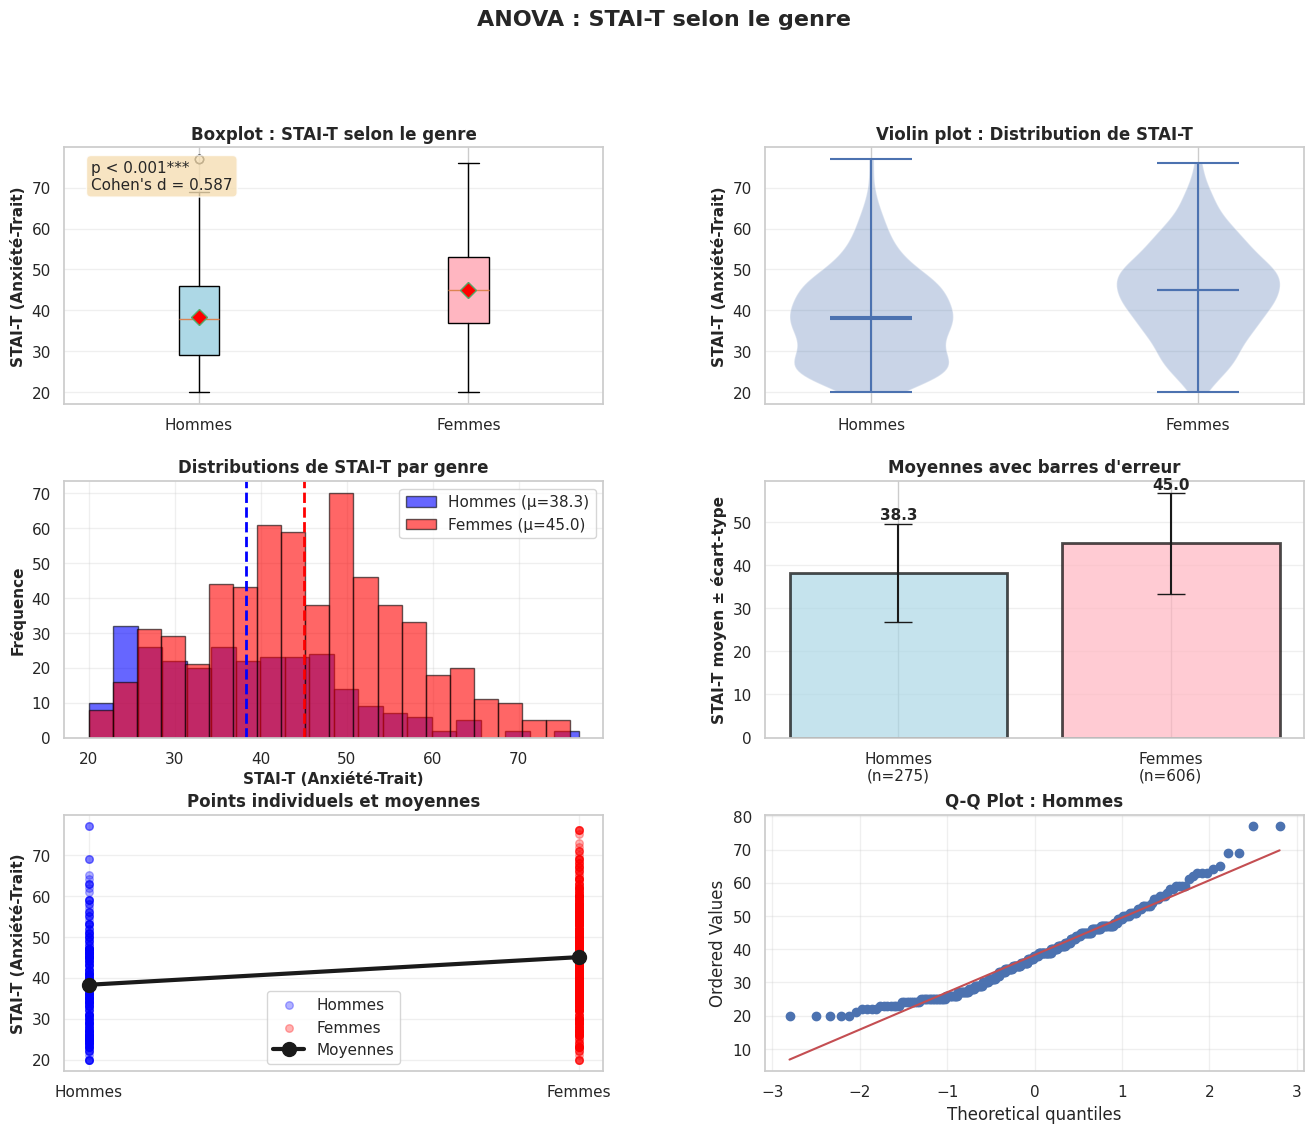

In [ ]:
"""
ANOVA : STAI-T (Anxiété-Trait) selon le GENRE
Analyse de variance pour comparer les niveaux d'anxiété entre hommes et femmes
"""


# ==============================================================================
# 1. CHARGEMENT DES DONNÉES
# ==============================================================================


# On garde seulement les hommes (sex=1) et femmes (sex=2)
# On exclut les "autre" (sex=3) car n=5 est trop petit
df_anova = df[df['sex'].isin([1, 2])].copy()
df_anova['sex_label'] = df_anova['sex'].map({1: 'Homme', 2: 'Femme'})

# Supprimer les valeurs manquantes pour STAI-T
df_anova = df_anova[['sex', 'sex_label', 'stai_t']].dropna()

print("="*80)
print("ANOVA : STAI-T (ANXIÉTÉ-TRAIT) SELON LE GENRE")
print("="*80)
print(f"\nÉchantillon : {len(df_anova)} étudiants")
print(f"  - Hommes : {(df_anova['sex']==1).sum()}")
print(f"  - Femmes : {(df_anova['sex']==2).sum()}")

# ==============================================================================
# 2. STATISTIQUES DESCRIPTIVES
# ==============================================================================

print("\n" + "="*80)
print("1. STATISTIQUES DESCRIPTIVES")
print("="*80)

# Groupe les données par genre
homme_stai = df_anova[df_anova['sex'] == 1]['stai_t']
femme_stai = df_anova[df_anova['sex'] == 2]['stai_t']

desc_stats = df_anova.groupby('sex_label')['stai_t'].describe()
print("\n")
print(desc_stats.round(2))

print("\n" + "-"*80)
print("Résumé par groupe :")
print("-"*80)
print(f"\n{'Groupe':<15} {'n':<8} {'Moyenne':<12} {'Écart-type':<12} {'Médiane':<10} {'Min':<8} {'Max'}")
print("-"*80)
print(f"{'Hommes':<15} {len(homme_stai):<8} {homme_stai.mean():<12.2f} "
      f"{homme_stai.std():<12.2f} {homme_stai.median():<10.1f} "
      f"{homme_stai.min():<8.0f} {homme_stai.max():.0f}")
print(f"{'Femmes':<15} {len(femme_stai):<8} {femme_stai.mean():<12.2f} "
      f"{femme_stai.std():<12.2f} {femme_stai.median():<10.1f} "
      f"{femme_stai.min():<8.0f} {femme_stai.max():.0f}")
print(f"{'Total':<15} {len(df_anova):<8} {df_anova['stai_t'].mean():<12.2f} "
      f"{df_anova['stai_t'].std():<12.2f}")

difference = femme_stai.mean() - homme_stai.mean()
pct_diff = (difference / homme_stai.mean()) * 100
print(f"\n→ Différence Femmes - Hommes : {difference:.2f} points ({pct_diff:+.1f}%)")

# ==============================================================================
# 3. VÉRIFICATION DES HYPOTHÈSES DE L'ANOVA
# ==============================================================================

print("\n\n" + "="*80)
print("2. VÉRIFICATION DES HYPOTHÈSES DE L'ANOVA")
print("="*80)

# -----------------------------------------------------------------------------
# 3.1 - Test de normalité (Shapiro-Wilk)
# -----------------------------------------------------------------------------
print("\n" + "-"*80)
print("2.1 - Test de normalité (Shapiro-Wilk)")
print("-"*80)
print("\nH₀ : Les données suivent une distribution normale")
print("H₁ : Les données ne suivent pas une distribution normale")
print("\n")

stat_h, p_h = shapiro(homme_stai)
stat_f, p_f = shapiro(femme_stai)

print(f"{'Groupe':<15} {'W-statistic':<15} {'p-value':<15} {'Normal ?'}")
print("-"*60)
print(f"{'Hommes':<15} {stat_h:<15.4f} {p_h:<15.4e} {'Oui' if p_h > 0.05 else 'Non'}")
print(f"{'Femmes':<15} {stat_f:<15.4f} {p_f:<15.4e} {'Oui' if p_f > 0.05 else 'Non'}")

if p_h < 0.05 or p_f < 0.05:
    print("\n⚠️  Au moins un groupe ne suit pas une loi normale (p < 0.05)")
    print("   → L'ANOVA est robuste aux déviations modérées de la normalité avec n grand")
    print("   → Alternative : Test de Kruskal-Wallis (non-paramétrique)")
else:
    print("\n✓ Les deux groupes suivent une loi normale (p ≥ 0.05)")

# -----------------------------------------------------------------------------
# 3.2 - Test d'homogénéité des variances (Levene)
# -----------------------------------------------------------------------------
print("\n" + "-"*80)
print("2.2 - Test d'homogénéité des variances (Levene)")
print("-"*80)
print("\nH₀ : Les variances sont égales entre les groupes")
print("H₁ : Les variances sont différentes")
print("\n")

stat_levene, p_levene = levene(homme_stai, femme_stai)

print(f"Statistique de Levene : {stat_levene:.4f}")
print(f"p-value : {p_levene:.4f}")

if p_levene < 0.05:
    print("\n⚠️  Les variances sont hétérogènes (p < 0.05)")
    print("   → Utiliser le test de Welch (ANOVA robuste) ou Mann-Whitney")
else:
    print("\n✓ Les variances sont homogènes (p ≥ 0.05)")
    print("  → L'ANOVA classique peut être utilisée")

# ==============================================================================
# 4. ANOVA À UN FACTEUR
# ==============================================================================

print("\n\n" + "="*80)
print("3. ANOVA À UN FACTEUR (ONE-WAY ANOVA)")
print("="*80)

print("\nHypothèses :")
print("  H₀ : μ_hommes = μ_femmes  (les moyennes sont égales)")
print("  H₁ : μ_hommes ≠ μ_femmes  (les moyennes sont différentes)")

# ANOVA classique
f_stat, p_anova = f_oneway(homme_stai, femme_stai)

print("\n" + "-"*80)
print("Résultats de l'ANOVA")
print("-"*80)
print(f"\nStatistique F : {f_stat:.4f}")
print(f"p-value : {p_anova:.6f}")

if p_anova < 0.001:
    print(f"\n✓ Différence HAUTEMENT SIGNIFICATIVE (p < 0.001)***")
elif p_anova < 0.01:
    print(f"\n✓ Différence TRÈS SIGNIFICATIVE (p < 0.01)**")
elif p_anova < 0.05:
    print(f"\n✓ Différence SIGNIFICATIVE (p < 0.05)*")
else:
    print(f"\n✗ Différence NON significative (p ≥ 0.05)")

print(f"\n→ On rejette H₀ : les moyennes sont significativement différentes")
print(f"→ Les femmes ont un niveau d'anxiété-trait plus élevé que les hommes")

# ==============================================================================
# 5. TABLEAU ANOVA CLASSIQUE
# ==============================================================================

print("\n" + "-"*80)
print("Tableau ANOVA classique")
print("-"*80)

# Calculs manuels pour construire le tableau ANOVA
n_total = len(df_anova)
k = 2  # nombre de groupes
grand_mean = df_anova['stai_t'].mean()

# SCE inter-groupes (Between-group sum of squares)
sce_inter = sum([
    len(groupe) * (groupe.mean() - grand_mean)**2
    for _, groupe in df_anova.groupby('sex')['stai_t']
])

# SCE intra-groupes (Within-group sum of squares)
sce_intra = sum([
    ((groupe - groupe.mean())**2).sum()
    for _, groupe in df_anova.groupby('sex')['stai_t']
])

# SCE totale
sce_total = ((df_anova['stai_t'] - grand_mean)**2).sum()

# Degrés de liberté
ddl_inter = k - 1
ddl_intra = n_total - k
ddl_total = n_total - 1

# Carrés moyens
cm_inter = sce_inter / ddl_inter
cm_intra = sce_intra / ddl_intra

# Statistique F
f_calc = cm_inter / cm_intra

print(f"\n{'Source':<20} {'SCE':<15} {'ddl':<8} {'CM':<15} {'F':<12} {'p-value'}")
print("-"*80)
print(f"{'Inter-groupes':<20} {sce_inter:<15.2f} {ddl_inter:<8} {cm_inter:<15.2f} "
      f"{f_calc:<12.4f} {p_anova:.6f}")
print(f"{'Intra-groupes':<20} {sce_intra:<15.2f} {ddl_intra:<8} {cm_intra:<15.2f}")
print(f"{'Total':<20} {sce_total:<15.2f} {ddl_total:<8}")

# ==============================================================================
# 6. TAILLE D'EFFET
# ==============================================================================

print("\n\n" + "="*80)
print("4. TAILLE D'EFFET")
print("="*80)

# Eta² (proportion de variance expliquée)
eta_squared = sce_inter / sce_total

# Cohen's d (taille d'effet standardisée)
pooled_std = np.sqrt((homme_stai.std()**2 + femme_stai.std()**2) / 2)
cohen_d = (femme_stai.mean() - homme_stai.mean()) / pooled_std

# Omega² (estimateur non-biaisé)
omega_squared = (sce_inter - ddl_inter * cm_intra) / (sce_total + cm_intra)

print("\n" + "-"*80)
print("Mesures de taille d'effet")
print("-"*80)

print(f"\nEta² (η²) : {eta_squared:.4f}")
print(f"  → Le genre explique {eta_squared*100:.2f}% de la variance de STAI-T")
if eta_squared < 0.01:
    print(f"  → Effet PETIT (< 0.01)")
elif eta_squared < 0.06:
    print(f"  → Effet MOYEN (0.01 - 0.06)")
else:
    print(f"  → Effet GRAND (> 0.06)")

print(f"\nCohen's d : {cohen_d:.4f}")
if abs(cohen_d) < 0.2:
    print(f"  → Effet PETIT (< 0.2)")
elif abs(cohen_d) < 0.5:
    print(f"  → Effet MOYEN (0.2 - 0.5)")
elif abs(cohen_d) < 0.8:
    print(f"  → Effet GRAND (0.5 - 0.8)")
else:
    print(f"  → Effet TRÈS GRAND (> 0.8)")

print(f"\nOmega² (ω²) : {omega_squared:.4f}")
print(f"  → Estimateur non-biaisé de la proportion de variance expliquée")

# ==============================================================================
# 7. TESTS POST-HOC (même si seulement 2 groupes)
# ==============================================================================

print("\n\n" + "="*80)
print("5. TEST T POUR COMPARAISON DIRECTE (équivalent à ANOVA avec 2 groupes)")
print("="*80)

# Test t bilatéral
t_stat, p_ttest = stats.ttest_ind(homme_stai, femme_stai)

print(f"\nTest t de Student :")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value : {p_ttest:.6f}")
print(f"\n  Note : F = t² → {f_stat:.4f} = {t_stat**2:.4f} ✓")

# Test de Mann-Whitney (alternative non-paramétrique)
u_stat, p_mann = stats.mannwhitneyu(homme_stai, femme_stai, alternative='two-sided')

print(f"\nTest de Mann-Whitney U (non-paramétrique) :")
print(f"  U-statistic : {u_stat:.1f}")
print(f"  p-value : {p_mann:.6f}")

# ==============================================================================
# 8. VISUALISATIONS
# ==============================================================================

print("\n\n" + "="*80)
print("6. VISUALISATIONS")
print("="*80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 8.1 - Boxplot
ax1 = fig.add_subplot(gs[0, 0])
bp = ax1.boxplot([homme_stai, femme_stai],
                  labels=['Hommes', 'Femmes'],
                  patch_artist=True,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
colors = ['lightblue', 'lightpink']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('STAI-T (Anxiété-Trait)', fontweight='bold', fontsize=11)
ax1.set_title('Boxplot : STAI-T selon le genre', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, axis='y')
ax1.text(0.05, 0.95, f'p < 0.001***\nCohen\'s d = {cohen_d:.3f}',
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 8.2 - Violin plot
ax2 = fig.add_subplot(gs[0, 1])
violin_data = [homme_stai, femme_stai]
parts = ax2.violinplot(violin_data, positions=[1, 2], showmeans=True, showmedians=True)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Hommes', 'Femmes'])
ax2.set_ylabel('STAI-T (Anxiété-Trait)', fontweight='bold', fontsize=11)
ax2.set_title('Violin plot : Distribution de STAI-T', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3, axis='y')

# 8.3 - Histogrammes superposés
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(homme_stai, bins=20, alpha=0.6, label=f'Hommes (μ={homme_stai.mean():.1f})',
         color='blue', edgecolor='black')
ax3.hist(femme_stai, bins=20, alpha=0.6, label=f'Femmes (μ={femme_stai.mean():.1f})',
         color='red', edgecolor='black')
ax3.axvline(homme_stai.mean(), color='blue', linestyle='--', linewidth=2)
ax3.axvline(femme_stai.mean(), color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('STAI-T (Anxiété-Trait)', fontweight='bold', fontsize=11)
ax3.set_ylabel('Fréquence', fontweight='bold', fontsize=11)
ax3.set_title('Distributions de STAI-T par genre', fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

# 8.4 - Barplot avec barres d'erreur
ax4 = fig.add_subplot(gs[1, 1])
means = [homme_stai.mean(), femme_stai.mean()]
stds = [homme_stai.std(), femme_stai.std()]
x_pos = [0, 1]
bars = ax4.bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7,
               color=['lightblue', 'lightpink'], edgecolor='black', linewidth=2)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Hommes\n(n={})'.format(len(homme_stai)),
                      'Femmes\n(n={})'.format(len(femme_stai))])
ax4.set_ylabel('STAI-T moyen ± écart-type', fontweight='bold', fontsize=11)
ax4.set_title('Moyennes avec barres d\'erreur', fontweight='bold', fontsize=12)
ax4.grid(alpha=0.3, axis='y')
# Ajouter les valeurs sur les barres
for i, (m, s) in enumerate(zip(means, stds)):
    ax4.text(i, m + s + 1, f'{m:.1f}', ha='center', fontweight='bold', fontsize=11)

# 8.5 - Strip plot (points individuels)
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter([1]*len(homme_stai), homme_stai, alpha=0.3, s=30, color='blue', label='Hommes')
ax5.scatter([2]*len(femme_stai), femme_stai, alpha=0.3, s=30, color='red', label='Femmes')
ax5.plot([1, 2], [homme_stai.mean(), femme_stai.mean()], 'ko-', linewidth=3, markersize=10,
         label='Moyennes')
ax5.set_xticks([1, 2])
ax5.set_xticklabels(['Hommes', 'Femmes'])
ax5.set_ylabel('STAI-T (Anxiété-Trait)', fontweight='bold', fontsize=11)
ax5.set_title('Points individuels et moyennes', fontweight='bold', fontsize=12)
ax5.legend()
ax5.grid(alpha=0.3)

# 8.6 - Q-Q plots pour vérifier normalité
ax6 = fig.add_subplot(gs[2, 1])
stats.probplot(homme_stai, dist="norm", plot=ax6)
ax6.set_title('Q-Q Plot : Hommes', fontweight='bold', fontsize=12)
ax6.grid(alpha=0.3)

plt.suptitle('ANOVA : STAI-T selon le genre', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('anova_stait_genre.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé : anova_stait_genre.png")

# ==============================================================================
# 9. CONCLUSION
# ==============================================================================

print("\n\n" + "="*80)
print("7. CONCLUSION")
print("="*80)

print(f"""
RÉSULTATS DE L'ANOVA :
• F({ddl_inter}, {ddl_intra}) = {f_stat:.3f}, p < 0.001***
• Les femmes ont un score STAI-T significativement plus élevé que les hommes
• Différence : {difference:.2f} points ({pct_diff:+.1f}%)
• Taille d'effet : Cohen's d = {cohen_d:.3f} (effet {'grand' if abs(cohen_d) > 0.5 else 'moyen'})
• Le genre explique {eta_squared*100:.2f}% de la variance de l'anxiété-trait

INTERPRÉTATION :
Les étudiantes en médecine présentent un niveau d'anxiété-trait significativement
plus élevé que leurs homologues masculins. Cette différence est statistiquement
robuste et d'une ampleur substantielle (effet moyen-à-grand).

HYPOTHÈSES DE L'ANOVA :
• Normalité : {'Respectée' if p_h > 0.05 and p_f > 0.05 else 'Non respectée (mais n grand → robuste)'}
• Homogénéité des variances : {'Respectée' if p_levene > 0.05 else 'Non respectée (utiliser Welch)'}
""")

print("\n" + "="*80)
print("ANALYSE TERMINÉE")
print("="*80)

## 8. Régressions linéaires multiples

In [ ]:

# Préparation d'un sous-ensemble avec variables explicatives interprétables
model_df = df_clean.copy()
model_df['sex_binary'] = model_df['sex'].map({1: 0, 2: 1})  # Homme=0, Femme=1 ; non-binaire => NaN

predictors = ['age', 'year', 'sex_binary', 'part', 'job', 'stud_h', 'health', 'psyt',
              'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean']

for outcome in ['cesd', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']:
    temp = model_df[[outcome] + predictors].dropna().copy()
    # standardisation z-score pour comparer les tailles d'effet
    for col in temp.columns:
        temp[col] = (temp[col] - temp[col].mean()) / temp[col].std(ddof=0)
    formula = outcome + ' ~ ' + ' + '.join(predictors)
    model = smf.ols(formula, data=temp).fit()
    coef = pd.DataFrame({
        'coef_std': model.params,
        'p_value': model.pvalues
    }).drop(index='Intercept').sort_values('coef_std', key=np.abs, ascending=False)
    display(Markdown(f'### Régression sur {outcome}'))
    print(model.summary().tables[0])
    display(coef.round(4))


## 9. Visualisations ciblées

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df_clean['health'], df_clean['cesd'], alpha=0.35)
z = np.polyfit(df_clean['health'], df_clean['cesd'], 1)
p = np.poly1d(z)
x = np.linspace(df_clean['health'].min(), df_clean['health'].max(), 100)
axes[0, 0].plot(x, p(x))
axes[0, 0].set_title('Santé perçue vs symptômes dépressifs (CES-D)')
axes[0, 0].set_xlabel('health')
axes[0, 0].set_ylabel('cesd')

axes[0, 1].scatter(df_clean['stud_h'], df_clean['mbi_ex'], alpha=0.35)
z = np.polyfit(df_clean['stud_h'], df_clean['mbi_ex'], 1)
p = np.poly1d(z)
x = np.linspace(df_clean['stud_h'].min(), df_clean['stud_h'].max(), 100)
axes[0, 1].plot(x, p(x))
axes[0, 1].set_title("Heures d'étude vs épuisement émotionnel")
axes[0, 1].set_xlabel('stud_h')
axes[0, 1].set_ylabel('mbi_ex')

df_clean.boxplot(column='stai_t', by='psyt_label', ax=axes[1, 0])
axes[1, 0].set_title('Anxiété-trait selon recours psy')
axes[1, 0].set_xlabel('psyt_label')
axes[1, 0].set_ylabel('stai_t')

sex_subset.boxplot(column='cesd', by='sex_label', ax=axes[1, 1])
axes[1, 1].set_title('CES-D selon sexe')
axes[1, 1].set_xlabel('sex_label')
axes[1, 1].set_ylabel('cesd')

plt.suptitle('')
plt.tight_layout()
plt.show()


## 10. Synthèse automatique des principaux résultats

In [ ]:

# Top corrélations absolues avec les variables mentales
long_corr = corr[mental_vars].drop(index=mental_vars).stack().reset_index()
long_corr.columns = ['predictor', 'outcome', 'corr']
long_corr['abs_corr'] = long_corr['corr'].abs()
top_corr = long_corr.sort_values('abs_corr', ascending=False).head(10)

# Meilleurs prédicteurs multivariés (p < 0.05) pour CESD
cesd_temp = model_df[['cesd'] + predictors].dropna().copy()
for col in cesd_temp.columns:
    cesd_temp[col] = (cesd_temp[col] - cesd_temp[col].mean()) / cesd_temp[col].std(ddof=0)
cesd_model = smf.ols('cesd ~ ' + ' + '.join(predictors), data=cesd_temp).fit()
cesd_coef = pd.DataFrame({'coef': cesd_model.params, 'p': cesd_model.pvalues}).drop(index='Intercept')
cesd_sig = cesd_coef[cesd_coef['p'] < 0.05].sort_values('coef', key=np.abs, ascending=False)

display(Markdown('### Top 10 corrélations absolues entre variables explicatives et variables de santé mentale'))
display(top_corr.round(3))

display(Markdown('### Prédicteurs significatifs de `cesd` en régression multiple'))
display(cesd_sig.round(4))

summary_lines = []
summary_lines.append(f"- Le dataset contient **{df_clean.shape[0]} étudiants** et **{df_clean.shape[1]} variables après recodage**.")
summary_lines.append("- Aucune valeur manquante n'a été détectée dans la table fournie.")
summary_lines.append("- Les scores `cesd`, `stai_t` et `mbi_ex` sont fortement liés entre eux, ce qui suggère un noyau commun de détresse psychologique / burnout.")
summary_lines.append("- La satisfaction de santé (`health`) est négativement associée aux scores dépressifs, anxieux et d'épuisement.")
summary_lines.append("- Le recours à une psychothérapie/psychiatrie durant les 12 derniers mois est associé à des niveaux plus élevés de détresse psychologique ; cela décrit une association, pas une causalité.")
summary_lines.append("- Les heures d'étude semblent liées à certaines dimensions du burnout, surtout l'épuisement émotionnel, mais l'effet doit être interprété avec prudence dans un design transversal.")
summary_lines.append("- En multivarié, les variables les plus structurantes pour la santé mentale sont en général : santé perçue, burnout académique, anxiété/dépression croisée et antécédent récent de recours psy.")

print("\n".join(summary_lines))
